In [1]:
import os
import warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


In [5]:

data_path = "/home/mini/projects/churn-clv-prediction-suite/data/raw/telco_churn.csv"
df = pd.read_csv(data_path)

print(f"Rows: {len(df.index)}")
print(f"Columns: {len(df.columns)}")
print(f"\nFirst 3 rows:")
df.head(3)

Rows: 7043
Columns: 21

First 3 rows:


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [8]:
df.describe(include='object')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [9]:
print(f"TotalCharges dtype: {df['TotalCharges'].dtype}")
df['TotalCharges_numeric'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
nan_count = df['TotalCharges_numeric'].isna().sum()
print(f"Non-numeric values found: {nan_count}")

if nan_count > 0:
    problematic = df[df['TotalCharges_numeric'].isna()]
    print(f"\nProblematic rows (showing tenure):")
    print(problematic[['customerID', 'tenure', 'TotalCharges', 'MonthlyCharges']].head(15))


TotalCharges dtype: object
Non-numeric values found: 11

Problematic rows (showing tenure):
      customerID  tenure TotalCharges  MonthlyCharges
488   4472-LVYGI       0                        52.55
753   3115-CZMZD       0                        20.25
936   5709-LVOEQ       0                        80.85
1082  4367-NUYAO       0                        25.75
1340  1371-DWPAZ       0                        56.05
3331  7644-OMVMY       0                        19.85
3826  3213-VVOLG       0                        25.35
4380  2520-SGTTA       0                        20.00
5218  2923-ARZLG       0                        19.70
6670  4075-WKNIU       0                        73.35
6754  2775-SEFEE       0                        61.90


In [10]:
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100

print("Churn distribution:")
print(churn_counts)
print(f"\nChurn rate: {churn_pct['Yes']:.2f}%")
print(f"Retention rate: {churn_pct['No']:.2f}%")


Churn distribution:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn rate: 26.54%
Retention rate: 73.46%


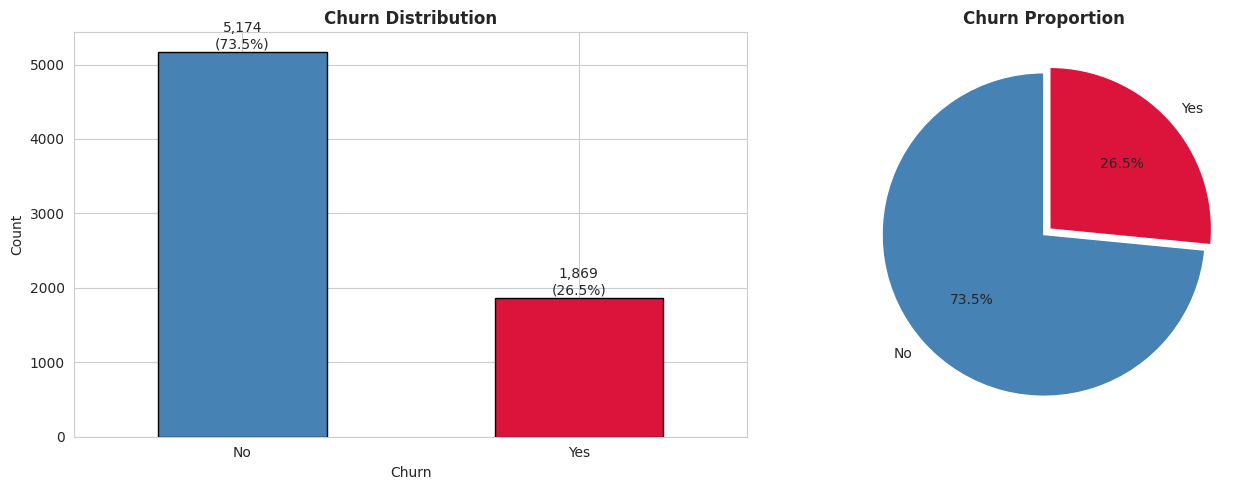

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

churn_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'crimson'], edgecolor='black')
axes[0].set_title('Churn Distribution', fontweight='bold')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v, f'{v:,}\n({churn_pct.values[i]:.1f}%)', ha='center', va='bottom')

axes[1].pie(churn_counts.values, labels=churn_counts.index, 
            colors=['steelblue', 'crimson'], autopct='%1.1f%%',
            startangle=90, explode=[0, 0.05])
axes[1].set_title('Churn Proportion', fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/01_telco_churn_distribution.png', dpi=100, bbox_inches='tight')
plt.show()

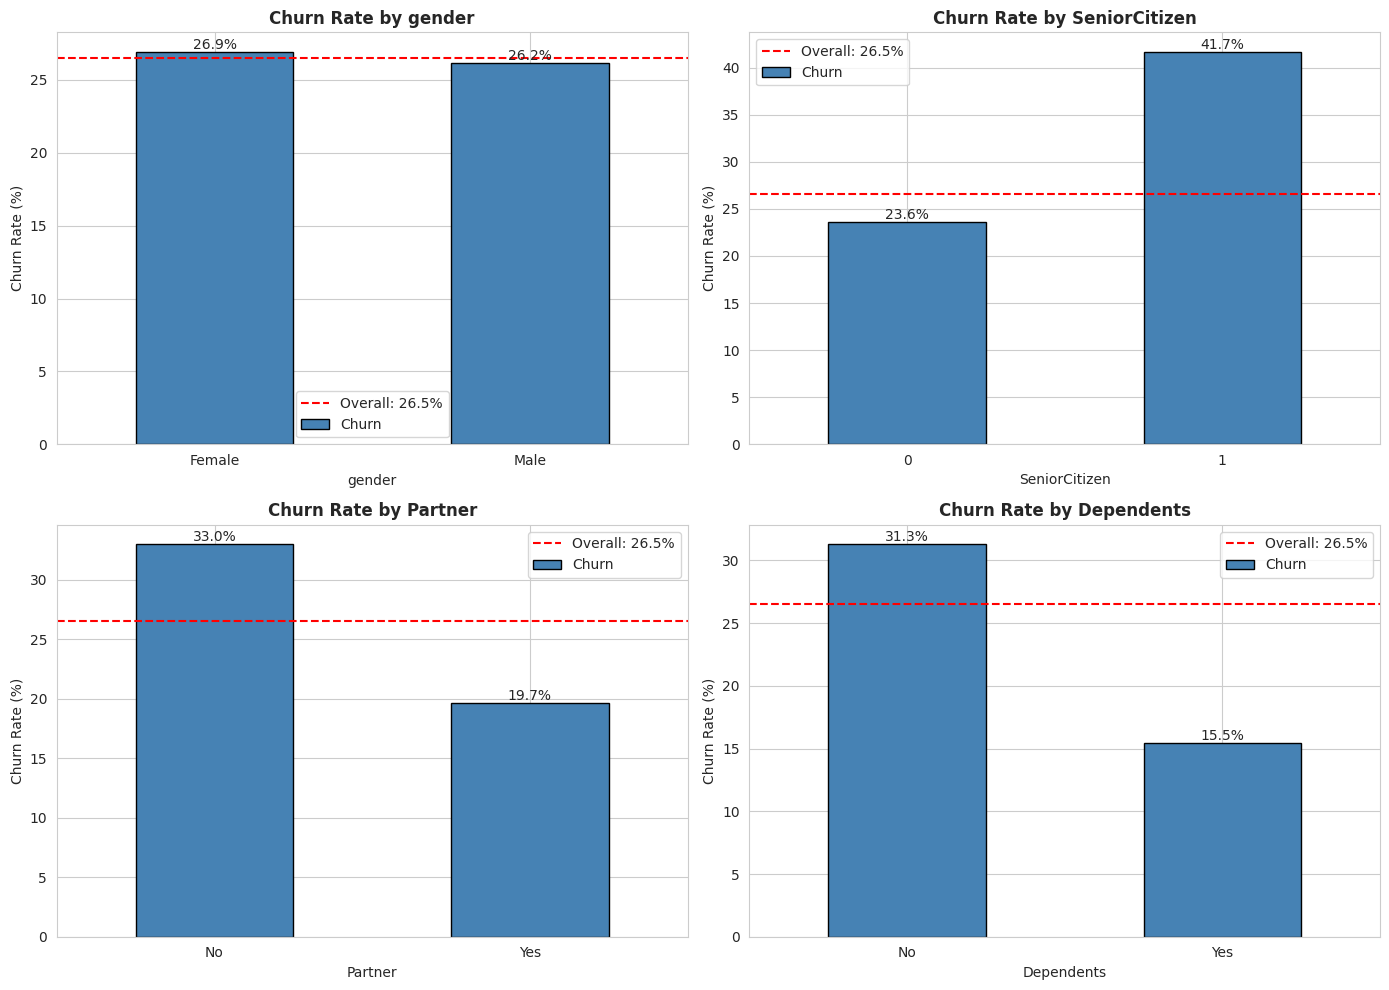

In [13]:
demographics = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(demographics):
    churn_by_cat = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    
    churn_by_cat.plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].axhline(y=churn_pct['Yes'], color='red', linestyle='--', label=f'Overall: {churn_pct["Yes"]:.1f}%')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=0)
    
    for j, v in enumerate(churn_by_cat.values):
        axes[i].text(j, v, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../reports/figures/02_telco_demographics_churn.png', dpi=100, bbox_inches='tight')
plt.show()

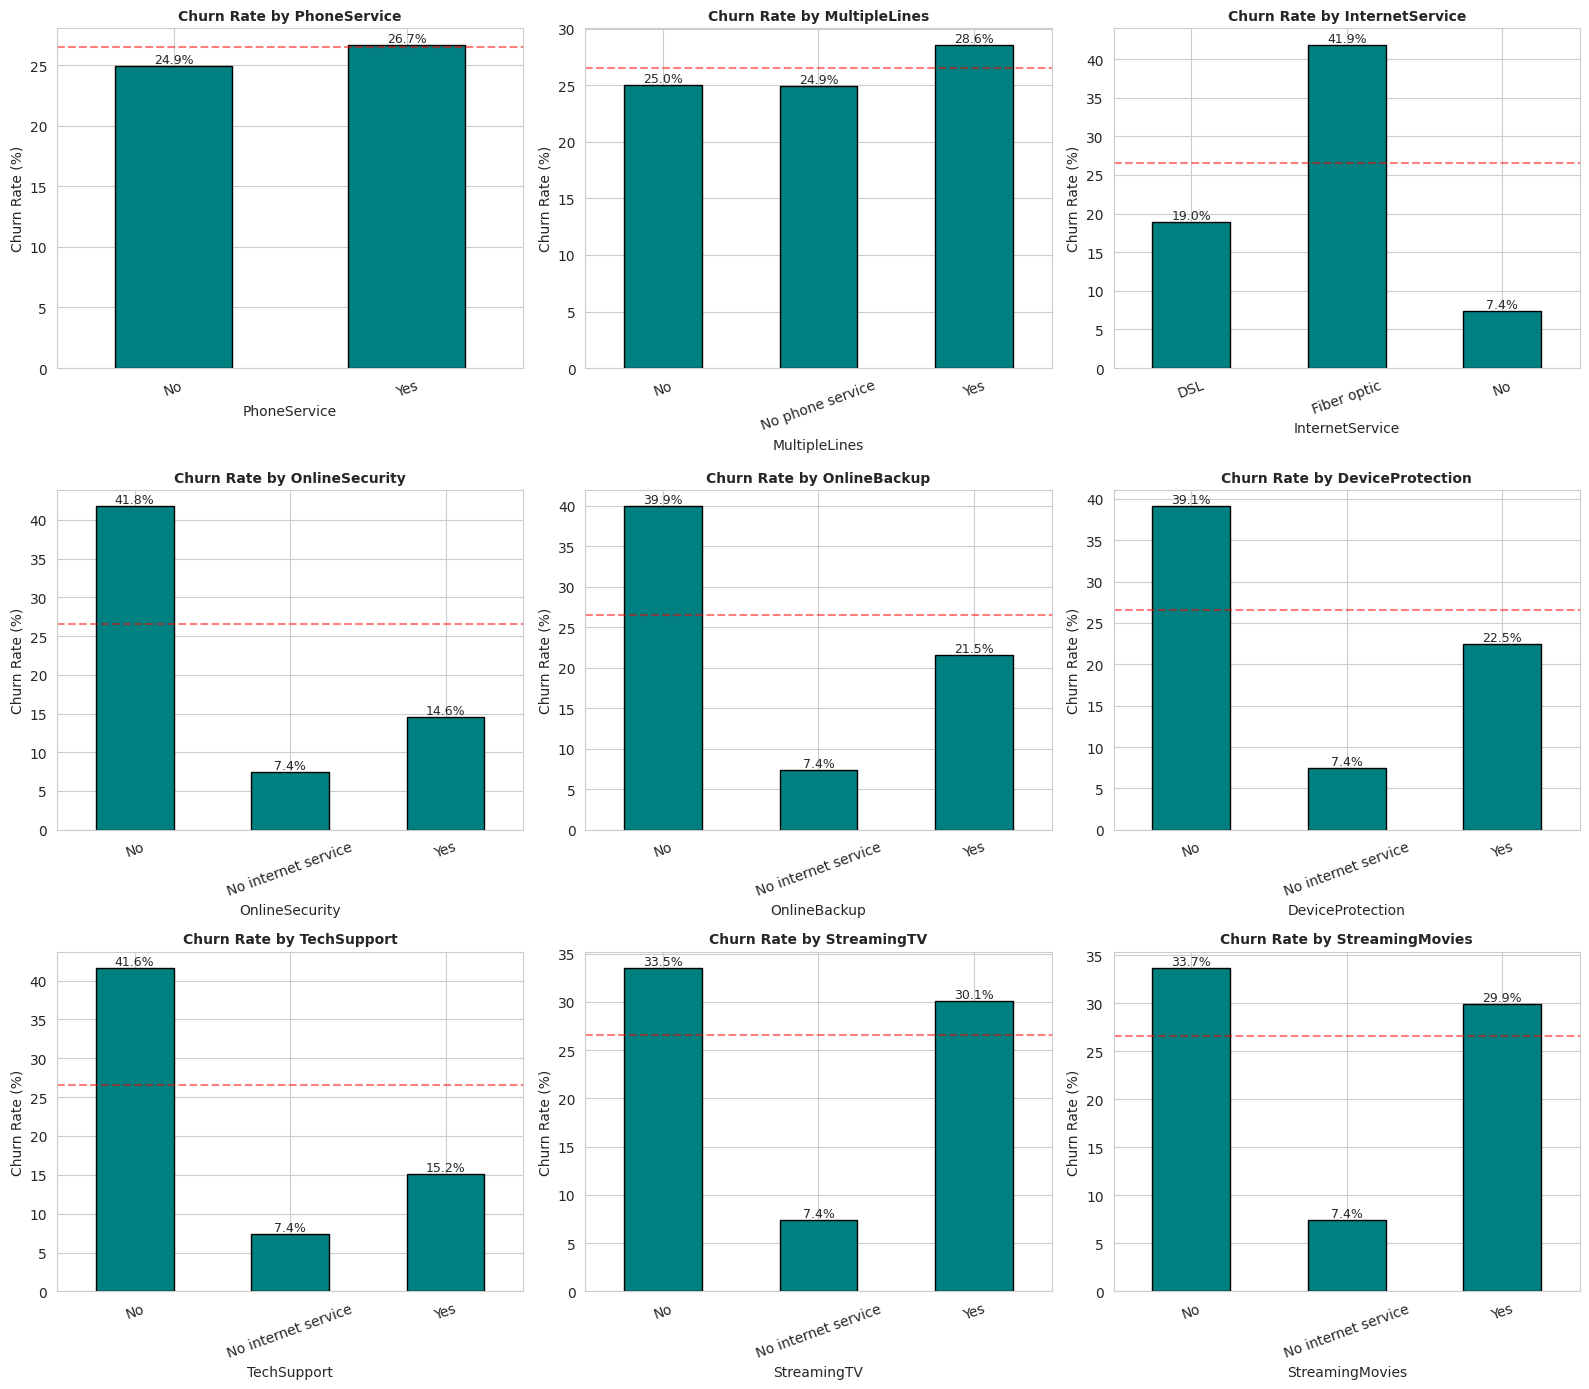

In [14]:
services = ['PhoneService', 'MultipleLines', 'InternetService', 
            'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
            'TechSupport', 'StreamingTV', 'StreamingMovies']

fig, axes = plt.subplots(3, 3, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(services):
    churn_by_cat = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100)
    
    churn_by_cat.plot(kind='bar', ax=axes[i], color='teal', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold', fontsize=10)
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].axhline(y=churn_pct['Yes'], color='red', linestyle='--', alpha=0.5)
    axes[i].tick_params(axis='x', rotation=20)
    
    for j, v in enumerate(churn_by_cat.values):
        axes[i].text(j, v, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('../reports/figures/03_telco_services_churn.png', dpi=100, bbox_inches='tight')
plt.show()

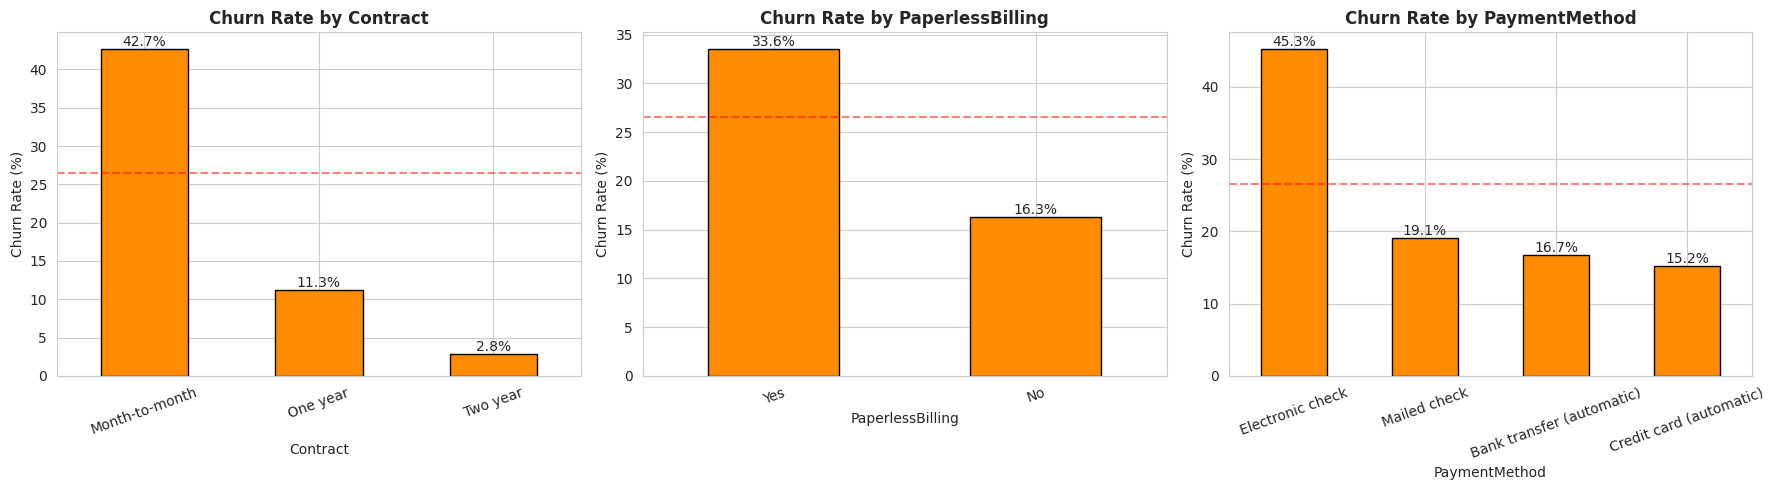

In [15]:
contract_features = ['Contract', 'PaperlessBilling', 'PaymentMethod']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, col in enumerate(contract_features):
    churn_by_cat = df.groupby(col)['Churn'].apply(lambda x: (x == 'Yes').mean() * 100).sort_values(ascending=False)
    
    churn_by_cat.plot(kind='bar', ax=axes[i], color='darkorange', edgecolor='black')
    axes[i].set_title(f'Churn Rate by {col}', fontweight='bold')
    axes[i].set_ylabel('Churn Rate (%)')
    axes[i].axhline(y=churn_pct['Yes'], color='red', linestyle='--', alpha=0.5)
    axes[i].tick_params(axis='x', rotation=20)
    
    for j, v in enumerate(churn_by_cat.values):
        axes[i].text(j, v, f'{v:.1f}%', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('../reports/figures/04_telco_contract_churn.png', dpi=100, bbox_inches='tight')
plt.show()

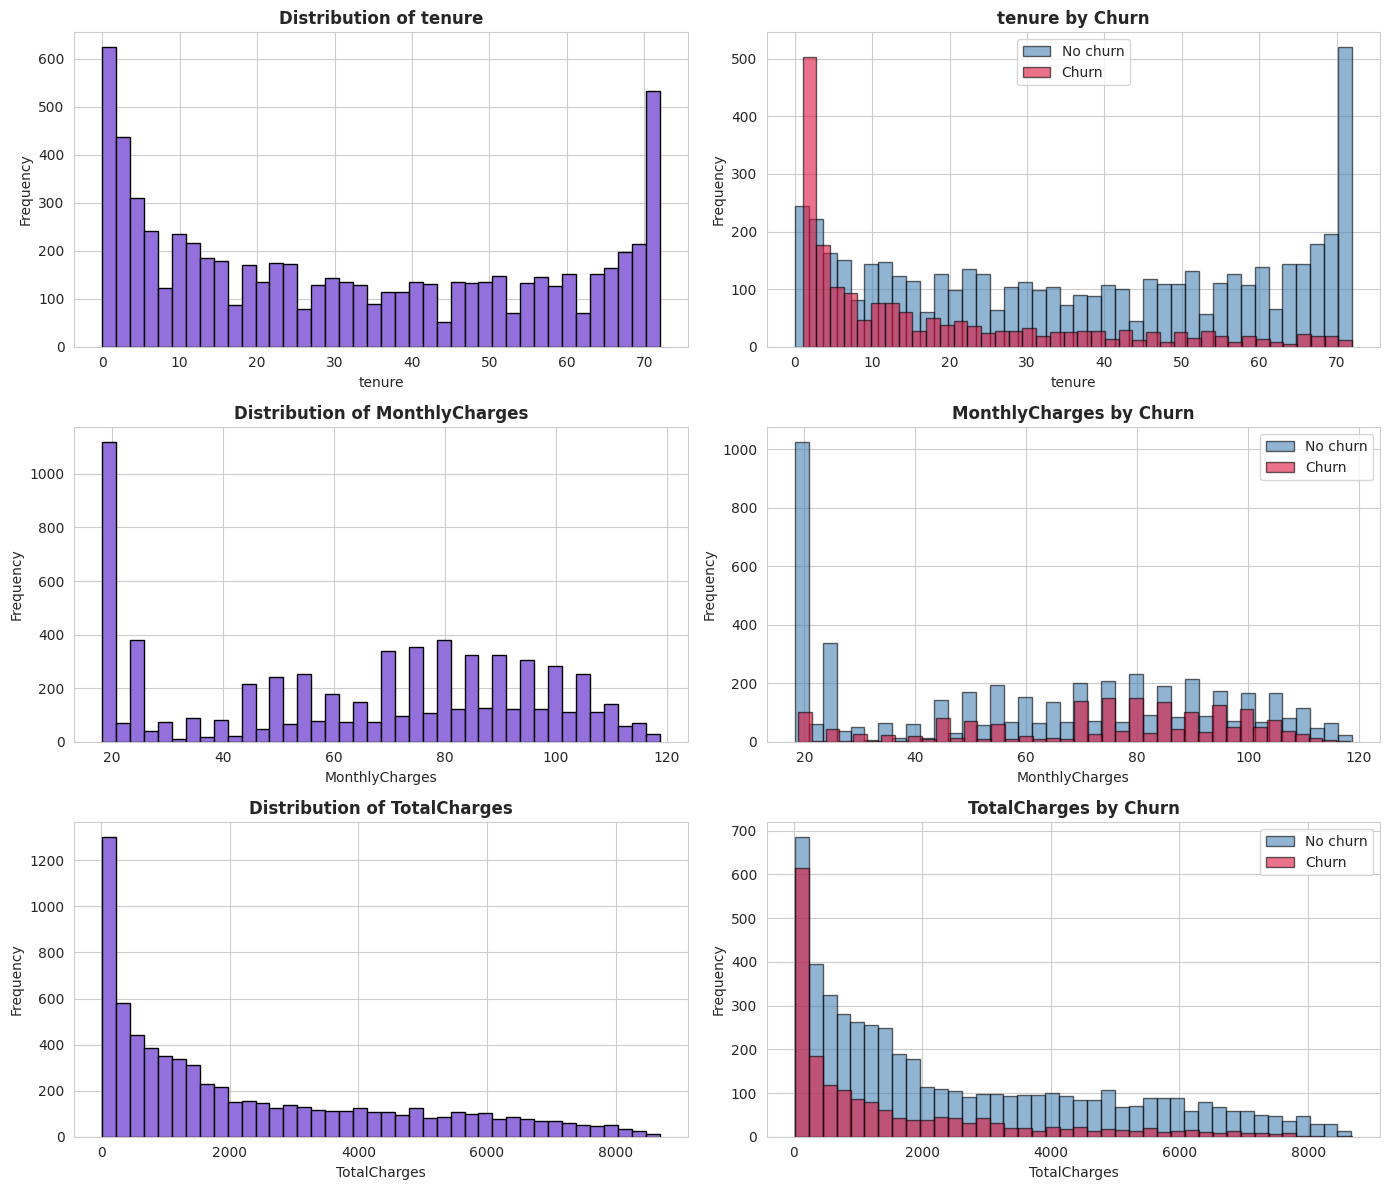

In [ ]:
df['TotalCharges'] = df['TotalCharges_numeric']  # use the cleaned version

numeric_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

for i, col in enumerate(numeric_features):
    
    df[col].hist(bins=40, ax=axes[i, 0], color='mediumpurple', edgecolor='black')
    axes[i, 0].set_title(f'Distribution of {col}', fontweight='bold')
    axes[i, 0].set_xlabel(col)
    axes[i, 0].set_ylabel('Frequency')
    
    df[df['Churn'] == 'No'][col].hist(bins=40, ax=axes[i, 1], 
                                        alpha=0.6, label='No churn', color='steelblue', edgecolor='black')
    df[df['Churn'] == 'Yes'][col].hist(bins=40, ax=axes[i, 1], 
                                         alpha=0.6, label='Churn', color='crimson', edgecolor='black')
    axes[i, 1].set_title(f'{col} by Churn', fontweight='bold')
    axes[i, 1].set_xlabel(col)
    axes[i, 1].set_ylabel('Frequency')
    axes[i, 1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/05_telco_numeric_distributions.png', dpi=100, bbox_inches='tight')
plt.show()

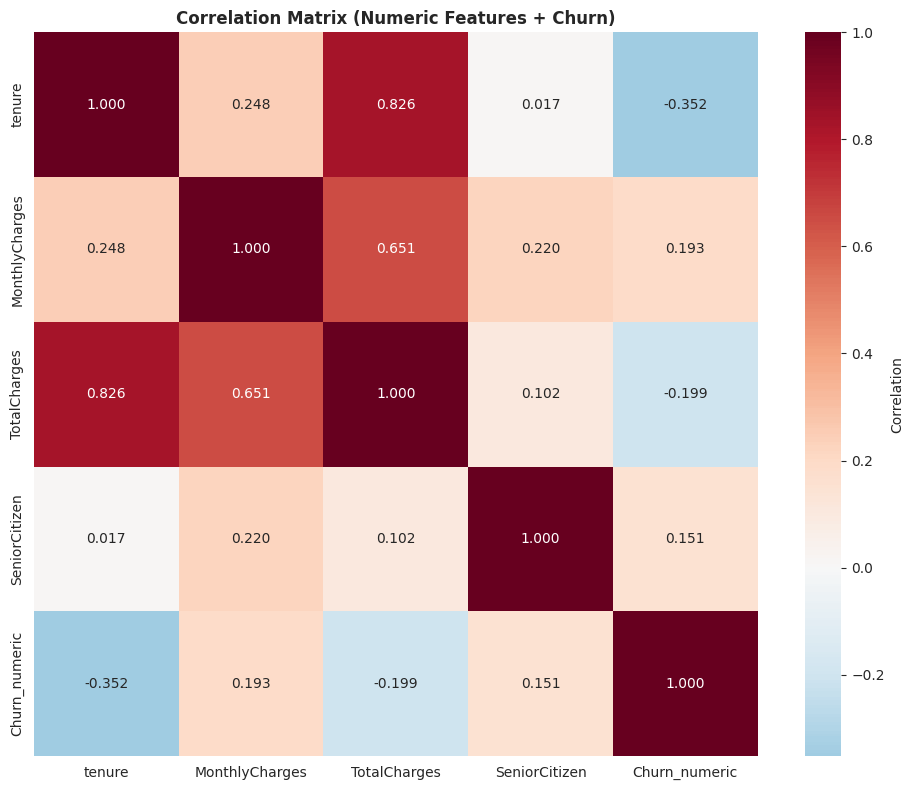


Correlations with Churn:
tenure           -0.352229
TotalCharges     -0.199484
SeniorCitizen     0.150889
MonthlyCharges    0.193356
Churn_numeric     1.000000
Name: Churn_numeric, dtype: float64


In [17]:
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'SeniorCitizen']
df_temp = df.copy()
df_temp['Churn_numeric'] = (df_temp['Churn'] == 'Yes').astype(int)

corr = df_temp[numeric_cols + ['Churn_numeric']].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, cbar_kws={'label': 'Correlation'}, ax=ax)
ax.set_title('Correlation Matrix (Numeric Features + Churn)', fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/06_telco_correlation_matrix.png', dpi=100, bbox_inches='tight')
plt.show()

print("\nCorrelations with Churn:")
print(corr['Churn_numeric'].sort_values())

In [18]:
print("="*70)
print("TELCO CHURN — EDA SUMMARY")
print("="*70)

print(f"\nDataset Size:")
print(f"  Customers: {len(df):,}")
print(f"  Features:  {df.shape[1]}")
print(f"  Churn rate: {churn_pct['Yes']:.2f}%")

print(f"\nData Quality:")
print(f"  Missing TotalCharges: 11 (tenure=0, new customers)")
print(f"  Other missing values: 0")

print(f"\nKey Patterns Identified:")
print(f"  - Month-to-month contracts have highest churn rate")
print(f"  - Low tenure customers (< 12 months) churn more")
print(f"  - High monthly charges correlate with churn")
print(f"  - Fiber optic internet users churn more than DSL")
print(f"  - Customers without partners/dependents churn more")
print(f"  - Senior citizens have higher churn rate")
print(f"  - Electronic check payment method has highest churn")

print(f"\nNext Steps:")
print(f"  1. Handle 11 NaN TotalCharges (impute or drop)")
print(f"  2. Encode categorical variables")
print(f"  3. Stratified train/test split on Churn")
print(f"  4. Try multiple classifiers (LogReg, RF, XGBoost, LightGBM)")
print(f"  5. Tune for ROC-AUC and business value")

TELCO CHURN — EDA SUMMARY

Dataset Size:
  Customers: 7,043
  Features:  22
  Churn rate: 26.54%

Data Quality:
  Missing TotalCharges: 11 (tenure=0, new customers)
  Other missing values: 0

Key Patterns Identified:
  - Month-to-month contracts have highest churn rate
  - Low tenure customers (< 12 months) churn more
  - High monthly charges correlate with churn
  - Fiber optic internet users churn more than DSL
  - Customers without partners/dependents churn more
  - Senior citizens have higher churn rate
  - Electronic check payment method has highest churn

Next Steps:
  1. Handle 11 NaN TotalCharges (impute or drop)
  2. Encode categorical variables
  3. Stratified train/test split on Churn
  4. Try multiple classifiers (LogReg, RF, XGBoost, LightGBM)
  5. Tune for ROC-AUC and business value
